In [86]:
import sys
sys.path.append('../../utils')
from functions import * 

In [87]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [88]:
import cell_state_asign_consistency
reload  (cell_state_asign_consistency)

<module 'cell_state_asign_consistency' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/cell_state_asign_consistency.py'>

In [89]:
import betabinomo_mix_singlecells
reload (betabinomo_mix_singlecells)

<module 'betabinomo_mix_singlecells' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py'>

In [90]:
# reload load_cluster_data
import load_cluster_data
reload (load_cluster_data)

<module 'load_cluster_data' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/load_cluster_data.py'>

In [91]:
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

### Settings and Load data

In [123]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 100 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., 
    "pi_prior" : 1.
}

print(hypers["eta"])

cpu
0.01


### load_cluster_data takes

In [124]:
# this folder contains input data for each tissue cell type sample
organ="Lymph_Node"
input_files_folder="/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/"+organ+"/"

final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, has_genes="yes") 

Reading in data from folder ...
/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Lymph_Node/


Finished reading in data from folder ...
['regulatory T cell' 'regulatory t cell' 'endothelial cell' 'nk cell'
 'non-classical monocyte' 'erythrocyte' 'conventional dendritic cell'
 'B cell' 'enodthelial cell' 'naive b cell' 'intermediate monocyte'
 'T cell' 'cd141-positive myeloid dendritic cell' 'mast cell'
 'CD1c-positive myeloid dendritic cell'
 'cd1c-positive myeloid dendritic cell'
 'cd8-positive, alpha-beta memory t cell'
 'CD8-positive alpha-beta thymocyte'
 'cd4-positive, alpha-beta memory t cell' 'innate lymphoid cell'
 'naive thymus-derived cd4-positive, alpha-beta t cell' 'macrophage'
 'plasma cell' 'memory b cell' 'classical monocyte' 'NK T cell'
 'CD4-positive alpha-beta thymocyte']
2383
91353
                                             cell_id  Cluster  Cluster_Counts  \
0  TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...       64             239   
1  TSP7_LymphNode_inguinal_SS2_B134143_B133906_Im...       64             239   
2  TSP7_LymphNode_inguinal_SS2_B134143_B

In [125]:
print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))

The number of junctions is:  91354
The number of intron clusters observed is:  20952
The number of genes is:  11252


In [126]:
# ensure that in coo_counts_sparse.shape = (n_cells, n_genes) , n_cells is the same number as cell_ids_conversion.shape = (n_cells, num_variables)
assert coo_counts_sparse.shape[0] == cell_ids_conversion.shape[0]

In [127]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
2383
2383


In [128]:
# what is the breadkdown of cell types in the data 
cell_ids_conversion['cell_type'].value_counts()

innate lymphoid cell                                    513
B cell                                                  441
memory b cell                                           400
naive thymus-derived cd4-positive, alpha-beta t cell    233
cd4-positive, alpha-beta memory t cell                  193
CD4-positive alpha-beta thymocyte                       117
cd8-positive, alpha-beta memory t cell                  114
plasma cell                                              94
T cell                                                   93
CD8-positive alpha-beta thymocyte                        54
nk cell                                                  53
mast cell                                                13
regulatory T cell                                        11
naive b cell                                             11
intermediate monocyte                                     7
endothelial cell                                          6
cd141-positive myeloid dendritic cell   

In [129]:
# set random seed
torch.manual_seed(0)

num_trials = 20 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()

# Running for just one K and assessing similarity across trials 

results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]


# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

Initialize VI params
Initializing variational parameters with N = 2383 cells and J = 91354 junctions
Got the initial ELBO ^
ELBO converged @ -970101696.0 CAVI iteration # 4 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 2383 cells and J = 91354 junctions
Got the initial ELBO ^
ELBO converged @ -970139648.0 CAVI iteration # 4 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 2383 cells and J = 91354 junctions
Got the initial ELBO ^
ELBO converged @ -970612992.0 CAVI iteration # 4 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 2383 cells and J = 91354 junctions
Got the initial ELBO ^
ELBO converged @ -970053440.0 CAVI iteration # 4 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 2383 cells and J = 91354 junctions
Got the initial ELBO ^
ELBO converged @ -969932864.0 CAVI iteration # 4 complete
Finished CAVI!
Initialize VI p

In [130]:
len(results)

20

### Evaluate the learned posteriors

The trial with the highest ELBO was 13


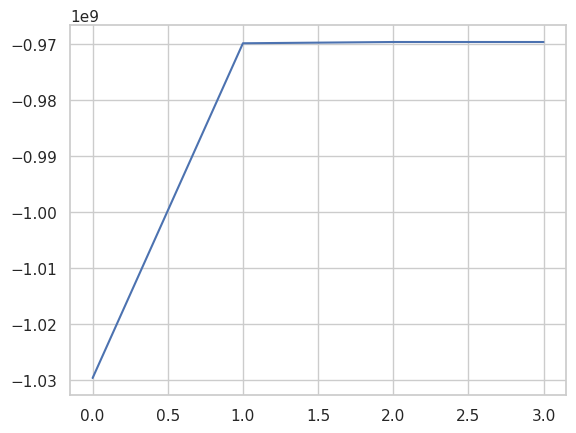

In [131]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

In [132]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()

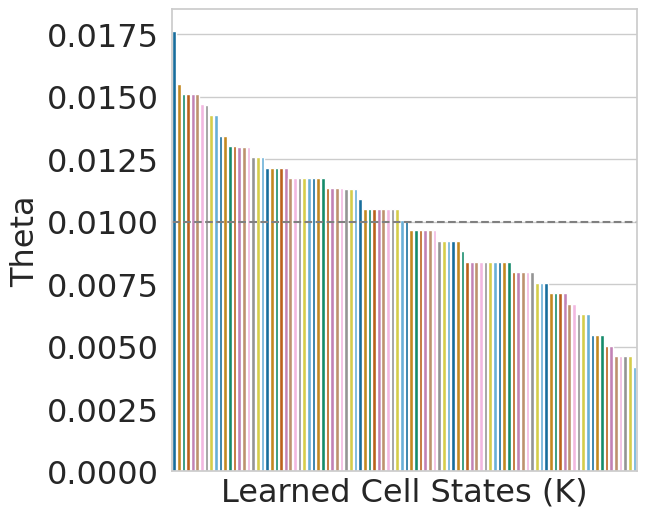

In [133]:
# How much is each cell state is used globally 

# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

# rename cell_state to be from 0 to K-1 based on order in sorted_cell_states
GAMMA_f_plot.head()

GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

# Make barplot using sns
plt.figure(figsize=(6, 6))
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
plt.axhline(0.01, ls='--', color='grey')

# Make Y label say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=23)
plt.xlabel("Learned Cell States (K)", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)
plt.show()

In [134]:
GAMMA_f_plot.head()

,theta,cell_state,new_cell_state
51,0.017622,51,0
32,0.015524,32,1
89,0.015108,89,2
7,0.015105,7,3
87,0.015105,87,4


In [135]:
final_data.cell_type.unique()

array(['cd4-positive, alpha-beta memory t cell',
       'cd8-positive, alpha-beta memory t cell',
       'naive thymus-derived cd4-positive, alpha-beta t cell',
       'memory b cell', 'innate lymphoid cell', 'intermediate monocyte',
       'cd1c-positive myeloid dendritic cell', 'naive b cell',
       'plasma cell', 'mast cell', 'nk cell', 'endothelial cell',
       'cd141-positive myeloid dendritic cell', 'regulatory t cell',
       'macrophage', 'B cell', 'T cell',
       'CD8-positive alpha-beta thymocyte',
       'CD4-positive alpha-beta thymocyte', 'regulatory T cell',
       'NK T cell', 'conventional dendritic cell', 'classical monocyte',
       'non-classical monocyte', 'enodthelial cell', 'erythrocyte',
       'CD1c-positive myeloid dendritic cell'], dtype=object)

In [139]:
cell_types_summary=cell_ids_conversion['cell_type'].value_counts()
cell_types_summary=pd.DataFrame(cell_types_summary)
cell_types_summary.reset_index(inplace=True)
cell_types_summary.columns=['cell_type','count']
# get percentage of each cell type in the data 
cell_types_summary['percentage']=cell_types_summary['count']/cell_types_summary['count'].sum()
cell_types_summary.sort_values(by='percentage',ascending=False,inplace=True)
print(cell_types_summary)
# plot barplot similar to above with thetas 

                                            cell_type  count  percentage
0                                innate lymphoid cell    513    0.215275
1                                              B cell    441    0.185061
2                                       memory b cell    400    0.167856
3   naive thymus-derived cd4-positive, alpha-beta ...    233    0.097776
4              cd4-positive, alpha-beta memory t cell    193    0.080990
5                   CD4-positive alpha-beta thymocyte    117    0.049098
6              cd8-positive, alpha-beta memory t cell    114    0.047839
7                                         plasma cell     94    0.039446
8                                              T cell     93    0.039026
9                   CD8-positive alpha-beta thymocyte     54    0.022661
10                                            nk cell     53    0.022241
11                                          mast cell     13    0.005455
13                                       naive b ce

In [140]:
# let's retain only the cell states that are used more than 1% of the time
GAMMA_f_plot = GAMMA_f_plot[GAMMA_f_plot["theta"] > 0.01]
GAMMA_f_plot.index.values

array([51, 32, 89,  7, 87,  1, 90, 10,  5, 26, 15, 52, 62,  2, 93, 59, 96,
       81, 78, 91, 39, 40, 69, 66, 55, 27, 98, 65, 88,  4, 58,  9, 84, 30,
       13, 85, 53, 56, 97, 20, 60, 28, 83, 76, 95, 16, 86, 41, 12, 77, 42])

In [141]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

# Keep only cell states defined above GAMMA_f_plot.index.values
PHI_f = PHI_f.loc[:, GAMMA_f_plot.index.values]
PHI_f

,51,32,89,7,87,1,90,10,5,26,...,28,83,76,95,16,86,41,12,77,42
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2379,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2381,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [142]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i+1) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values
PHI_f.groupby('cell_type').sum()

/scratch/ipykernel_515/1031914918.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,...,CellState_42,CellState_43,CellState_44,CellState_45,CellState_46,CellState_47,CellState_48,CellState_49,CellState_50,CellState_51
cell_type,,,,,,,,,,,,,,,,,,,,,
B cell,9.000000e+00,4.000000,8.000000,12.000000,1.000000,1.000000e+01,6.000000,8.000000e+00,3.000000,5.000000,...,4.000000,4.000000,6.000000,5.000000,6.000000,7.000000,2.000000e+00,3.000000e+00,3.000000,5.000000e+00
CD1c-positive myeloid dendritic cell,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
CD4-positive alpha-beta thymocyte,1.000000e+00,3.000000,0.000000,4.000000,1.000000,3.000000e+00,3.000000,4.000000e+00,2.000000,2.000000,...,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000e+00,2.000000e+00,2.000000,1.000000e+00
CD8-positive alpha-beta thymocyte,0.000000e+00,2.000000,1.000000,0.000000,1.000000,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,...,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000,0.000000e+00
NK T cell,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
T cell,2.000000e+00,1.000000,2.000000,1.000000,3.000000,1.000000e+00,1.000000,2.000000e+00,0.000000,2.000000,...,0.000000,0.000000,1.000000,0.000000,3.000000,1.000000,0.000000e+00,1.000000e+00,1.000000,0.000000e+00
cd141-positive myeloid dendritic cell,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
cd1c-positive myeloid dendritic cell,0.000000e+00,0.000000,1.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
"cd4-positive, alpha-beta memory t cell",2.000000e+00,4.000000,3.000000,1.000000,5.000000,1.000000e+00,3.000000,2.000000e+00,0.000000,4.000000,...,2.000000,1.000000,4.000000,3.000000,3.000000,0.000000,2.000000e+00,2.000000e+00,0.000000,5.000000e+00


In [143]:
PHI_f.shape # 29 cell states kept 

(2383, 53)

/scratch/ipykernel_515/2520592141.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/scratch/ipykernel_515/2520592141.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


{'CellState_1': ('plasma cell', 0.106), 'CellState_10': ('regulatory T cell', 0.091), 'CellState_11': ('NK T cell', 0.5), 'CellState_12': ('macrophage', 0.333), 'CellState_13': ('intermediate monocyte', 0.143), 'CellState_14': ('conventional dendritic cell', 1.0), 'CellState_15': ('cd141-positive myeloid dendritic cell', 0.167), 'CellState_16': ('naive b cell', 0.091), 'CellState_17': ('memory b cell', 0.028), 'CellState_18': ('enodthelial cell', 0.5), 'CellState_19': ('cd8-positive, alpha-beta memory t cell', 0.026), 'CellState_2': ('intermediate monocyte', 0.143), 'CellState_20': ('nk cell', 0.057), 'CellState_21': ('erythrocyte', 0.501), 'CellState_22': ('mast cell', 0.077), 'CellState_23': ('intermediate monocyte', 0.143), 'CellState_24': ('cd1c-positive myeloid dendritic cell', 0.2), 'CellState_25': ('plasma cell', 0.074), 'CellState_26': ('erythrocyte', 0.022), 'CellState_27': ('CD8-positive alpha-beta thymocyte', 0.037), 'CellState_28': ('intermediate monocyte', 0.143), 'CellSta

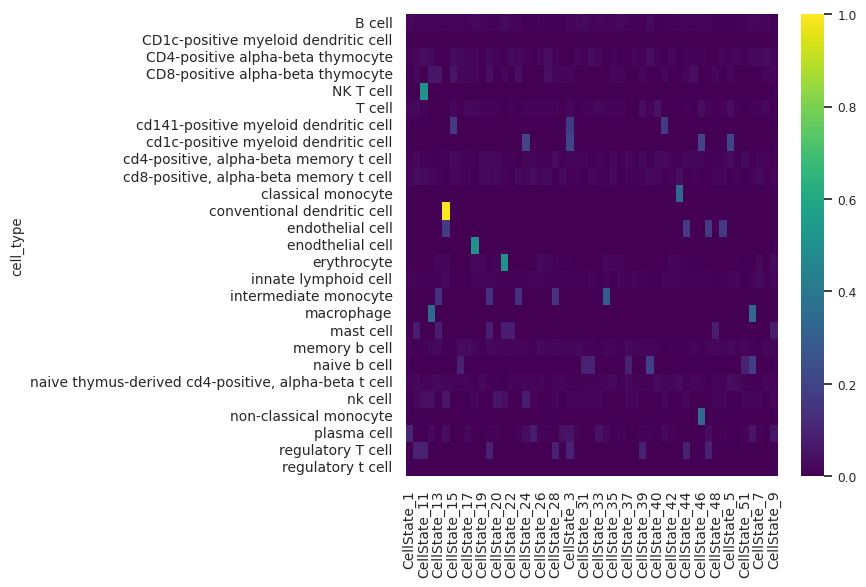

In [144]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(6, 6))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
sns.heatmap(sum_prop, annot=False, fmt=".2f", cmap='viridis')

# now let's give the cell states new labels based on what cell types they are associated with 
# go through sum_prop and for each cell state find the cell type with the highest proportion
# assign that cell type to the cell state
cell_type_labels = {}
for state in sum_prop.columns:
    max_prop = 0
    max_celltype = ''
    for celltype in sum_prop.index:
        if sum_prop.loc[celltype, state] > max_prop:
            max_prop = sum_prop.loc[celltype, state]
            max_celltype = celltype
    cell_type_labels[state] = max_celltype, round(max_prop, 3)
print(cell_type_labels)

In [145]:
# run fisher's exact test to see if the cell states are enriched for any cell types
from scipy.stats import fisher_exact

PHI_f_melt = pd.melt(PHI_f, id_vars=['cell_id', 'cell_type'], value_vars=PHI_f.columns[:-2])

# for each cell, choose cell state with highest probability
PHI_f_melt = PHI_f_melt.sort_values(by=['cell_id', 'value'], ascending=False).drop_duplicates(subset=['cell_id'])
PHI_f_melt.head()

,cell_id,cell_type,variable,value
90553,TSP7_LymphNode_supradiaphragmatic_SS2_B134156_...,B cell,CellState_38,1.0
2381,TSP7_LymphNode_supradiaphragmatic_SS2_B134156_...,innate lymphoid cell,CellState_1,0.0
2380,TSP7_LymphNode_supradiaphragmatic_SS2_B134156_...,plasma cell,CellState_1,0.0
64337,TSP7_LymphNode_supradiaphragmatic_SS2_B134156_...,plasma cell,CellState_27,1.0
57187,TSP7_LymphNode_supradiaphragmatic_SS2_B134156_...,innate lymphoid cell,CellState_24,1.0


## Do differential junction analysis 

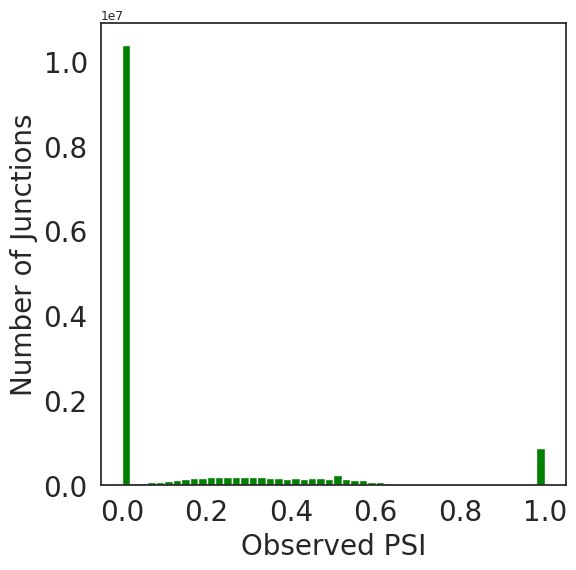

In [146]:
# plot histogram of observed junction usage ratios
plt.figure(figsize=(6, 6))
# make background white
sns.set_style("white")
plt.hist(final_data['juncratio'], bins=50, color='green')
plt.xlabel("Observed PSI", fontsize=20)
plt.ylabel("Number of Junctions", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [147]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
juncs_probs.shape

torch.Size([91354, 100])

In [148]:
alpha_plus_pi = ALPHA_f+PI_f
alpha_plus_pi.shape

torch.Size([91354, 100])

In [149]:
# Create boolean mask from tensor1
mask = alpha_plus_pi >= 10

# Apply the mask to tensor2 to get filtered values
filtered_values = juncs_probs[mask]

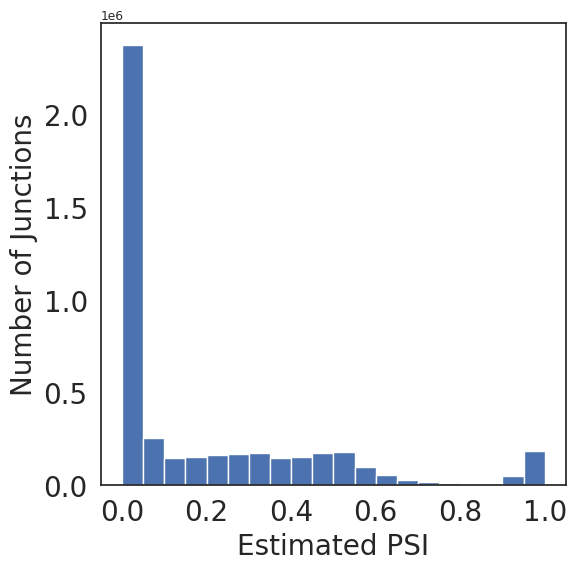

In [150]:
plt.figure(figsize=(6, 6))
# Plot the values
plt.hist(filtered_values.numpy(), bins=20)  # Assuming you want a histogram, adjust as needed
plt.xlabel('Estimated PSI', fontsize=20)
# Set y-label with larger font size (if you need it)
plt.ylabel('Number of Junctions', fontsize=20)  
# Increase tick label size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [151]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
# add "cell_state" to each column name 
juncs_probs_df.columns = ["cell_state_" + str(col+1) for col in juncs_probs_df.columns]
juncs_probs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values

In [152]:
# calculate sd deviation for each junction for cell states 0 to 19 
juncs_probs_df["sd"] = juncs_probs_df.iloc[:,0:K].std(axis=1)

In [153]:
juncs_probs_df

,cell_state_1,cell_state_2,cell_state_3,cell_state_4,cell_state_5,cell_state_6,cell_state_7,cell_state_8,cell_state_9,cell_state_10,...,cell_state_94,cell_state_95,cell_state_96,cell_state_97,cell_state_98,cell_state_99,cell_state_100,junction_id_index,junction_id,sd
0,0.307143,0.171008,0.290323,0.500000,0.241722,0.296252,0.186813,0.273070,0.274900,0.500000,...,0.171930,0.268293,0.278481,0.263398,0.008621,0.205607,0.500000,0,10_1001013_1005817,0.176083
1,0.003571,0.001133,0.016129,0.500000,0.003311,0.001209,0.005495,0.001883,0.000996,0.500000,...,0.003509,0.008130,0.004219,0.001140,0.008621,0.000519,0.500000,1,10_1001013_1007017,0.182302
2,0.003571,0.001133,0.016129,0.500000,0.003311,0.001209,0.005495,0.001883,0.000996,0.500000,...,0.003509,0.008130,0.004219,0.001140,0.008621,0.000519,0.500000,2,10_1001013_1008957,0.182834
3,0.500000,0.500000,0.250000,0.009009,0.066667,0.500000,0.500000,0.500000,0.286219,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.232558,0.500000,0.500000,3,10_100156234_100164003,0.128026
4,0.500000,0.500000,0.750000,0.009009,0.400000,0.500000,0.500000,0.500000,0.003534,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.023256,0.500000,0.500000,4,10_100156234_100174207,0.174634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91349,0.125000,0.008065,0.035714,0.066667,0.090909,0.014706,0.012658,0.008000,0.017857,0.038462,...,0.027027,0.200000,0.250000,0.008264,0.142857,0.014493,0.058824,91349,Y_57208979_57209531,0.170815
91350,0.625000,0.467742,0.250000,0.733333,0.545455,0.500000,0.177215,0.456000,0.375000,0.576923,...,0.270270,0.200000,0.750000,0.561983,0.428571,0.536232,0.588235,91350,Y_57209354_57209531,0.183597
91351,0.175676,0.555556,0.333333,0.200000,0.857143,0.444444,0.490132,0.458065,0.500000,0.350000,...,0.315789,0.450000,0.750000,0.541667,0.421053,0.542857,0.333333,91351,Y_57210792_57211551,0.164601
91352,0.013514,0.012346,0.037037,0.200000,0.142857,0.018519,0.003289,0.003226,0.035714,0.025000,...,0.052632,0.050000,0.250000,0.004630,0.052632,0.028571,0.047619,91352,Y_57210792_57211760,0.082039


In [154]:
# get likelihood ratio/bayes factor score for ALL junctions 
# let's compare just state X and Y

scores_all_juncs = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, ]
    b = PI_f[junc_index, ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)

,score,junction_id_index
58658,2.110618e+06,58658
58657,2.069398e+06,58657
58655,1.679388e+06,58655
58654,1.055157e+06,58654
58656,5.179898e+05,58656
50509,4.507810e+05,50509
50510,3.123647e+05,50510
15271,2.778479e+05,15271
58700,2.209905e+05,58700
15294,1.698484e+05,15294


In [155]:
# Compute the logistic score
scores_all_juncs_df["logistic_score"] = 1 / (1 + np.exp(-scores_all_juncs_df["score"]))

# Compute the Bayesian q-value for FDR
scores_all_juncs_df["q_value"] = 1 - scores_all_juncs_df["logistic_score"]
scores_all_juncs_df["significance"] = np.where(scores_all_juncs_df["q_value"] < 0.05, "yes", "no")

In [156]:
scores_all_juncs_df

,score,junction_id_index,logistic_score,q_value,significance
0,771.574219,0,1.0,0.0,yes
1,314.396118,1,1.0,0.0,yes
2,536.971313,2,1.0,0.0,yes
3,199.285583,3,1.0,0.0,yes
4,344.929932,4,1.0,0.0,yes
...,...,...,...,...,...
91349,309.709320,91349,1.0,0.0,yes
91350,188.537598,91350,1.0,0.0,yes
91351,189.229980,91351,1.0,0.0,yes
91352,173.842041,91352,1.0,0.0,yes


In [158]:
scores_all_juncs_df = scores_all_juncs_df.merge(junction_ids_conversion, on="junction_id_index").sort_values(by="score", ascending=False)

In [159]:
def quick_junc_plot(junc, simple_data, gene_name=None):
    simple_data_junc = simple_data[simple_data["junction_id_index"] == junc]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())

    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    if gene_name:
        plt.title("Junction:" + str(junc) + " Gene: " + simple_data_junc["gene_id"].values[0])
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)")
    plt.show()

In [161]:
def quick_clust_plot(clust, simple_data, gene_name=None):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())

    # how many cells from each cell type? let's only keep cell types with more than 10 cells here otherwise violin plot doesn't make sense
    # Modify y-tick labels to show only the portion after "Myeloid_" and split "oligodendrocyte_precursor_cell" over two lines

    # set figure size to be 6 by 7 
    plt.figure(figsize=(6, 6))
    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    if gene_name:
        plt.title("Cluster:" + str(clust) + " Gene: " + simple_data_junc["gene_id"].values[0], fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    # increase font size of title and xaxis and yaxis labels
    plt.xlabel("Observed PSI", fontsize=16)
    
    # Modify y-tick labels to show only the portion after "Myeloid_"
    plt.ylabel("Cell Type", fontsize=20)
    plt.xlabel("Observed PSI", fontsize=20)
    # increase font size of xticks and yticks
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=16)
    plt.show()

In [162]:
simple_data = final_data[["cell_id_index", "cell_type", "junction_id_index", "junc_count", "cluster_count"]]
simple_data = simple_data.merge(junction_ids_conversion, on="junction_id_index")
simple_data["junc_ratio"] = simple_data["junc_count"] / simple_data["cluster_count"]
simple_data.head()

,cell_id_index,cell_type,junction_id_index,junc_count,cluster_count,junction_id,Cluster,gene_id,junc_ratio
0,0,"cd4-positive, alpha-beta memory t cell",355,21.0,21,10_103392466_103396408,56741,ENSG00000173915.16,1.0
1,2,"naive thymus-derived cd4-positive, alpha-beta ...",355,25.0,25,10_103392466_103396408,56741,ENSG00000173915.16,1.0
2,3,"cd4-positive, alpha-beta memory t cell",355,9.0,9,10_103392466_103396408,56741,ENSG00000173915.16,1.0
3,4,memory b cell,355,21.0,21,10_103392466_103396408,56741,ENSG00000173915.16,1.0
4,15,"cd4-positive, alpha-beta memory t cell",355,57.0,57,10_103392466_103396408,56741,ENSG00000173915.16,1.0


In [163]:
# add percentile rank of score for each junction
scores_all_juncs_df["percentile_rank"] = scores_all_juncs_df["score"].rank(pct=True)
scores_all_juncs_df

,score,junction_id_index,logistic_score,q_value,significance,junction_id,Cluster,gene_id,percentile_rank
58658,2.110618e+06,58658,1.000000e+00,0.0,yes,2_88857683_88861885,18747,ENSG00000211592.8,1.000000
58657,2.069398e+06,58657,1.000000e+00,0.0,yes,2_88857683_88861524,18747,ENSG00000211592.8,0.999989
58655,1.679388e+06,58655,1.000000e+00,0.0,yes,2_88857683_88860885,18747,ENSG00000211592.8,0.999978
58654,1.055157e+06,58654,1.000000e+00,0.0,yes,2_88857683_88860567,18747,ENSG00000211592.8,0.999967
58656,5.179898e+05,58656,1.000000e+00,0.0,yes,2_88857683_88861220,18747,ENSG00000211592.8,0.999956
...,...,...,...,...,...,...,...,...,...
35196,-1.771875e+02,35196,1.118012e-77,1.0,no,19_48615946_48616078,96321,ENSG00000063177.13,0.000055
35246,-1.787500e+02,35246,2.343481e-78,1.0,no,19_48965609_48965769,93386,ENSG00000087086.15,0.000044
28219,-1.806875e+02,28219,3.376104e-79,1.0,no,17_4945997_4946627,88669,ENSG00000108518.8,0.000033
66866,-2.010000e+02,66866,5.091071e-88,1.0,no,4_151100588_151100974,26515,ENSG00000145425.10,0.000022


In [164]:
# check wd 
os.getcwd()

'/gpfs/commons/home/kisaev/Leaflet-analysis/tabula_sapien/Leaflet'

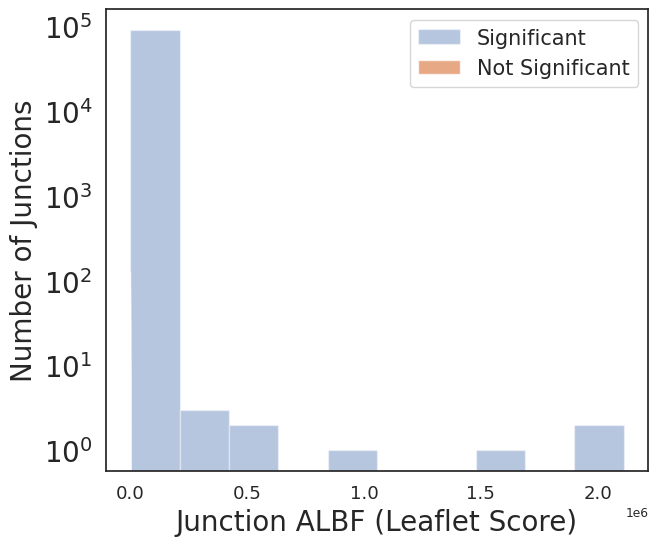

In [165]:
# Assuming you have significance data in scores_all_juncs_df
significant = scores_all_juncs_df[scores_all_juncs_df["significance"] == "yes"]["score"]
not_significant = scores_all_juncs_df[scores_all_juncs_df["significance"] == "no"]["score"]

plt.figure(figsize=(7, 6))

# Plot histograms
plt.hist(significant, bins=10, label='Significant', log=True, alpha=0.4)
plt.hist(not_significant, bins=10, label='Not Significant', log=True, alpha=0.7)

# Adjust labels, legend, and ticks
plt.xlabel("Junction ALBF (Leaflet Score)", fontsize=20)
plt.ylabel("Number of Junctions", fontsize=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=20)
plt.legend(loc='upper right', fontsize=15)

plt.show()


In [166]:
# only show scores for junctions that had decent certainty for ALPHA+BETA  
# turn alpha_plus_pi into dataframe 
alpha_plus_pi_df = pd.DataFrame(alpha_plus_pi, columns = range(K))
alpha_plus_pi_df["junction_id_index"] = alpha_plus_pi_df.index
# now melt alpha_plus_pi_df 
alpha_plus_pi_df_melt = pd.melt(alpha_plus_pi_df, id_vars=['junction_id_index'], value_vars=alpha_plus_pi_df.columns[:-1])
# rename columns to be "cell_state" and "alpha_plus_pi"
alpha_plus_pi_df_melt.columns = ["junction_id_index", "cell_state", "alpha_plus_pi"]
alpha_plus_pi_df_melt.head()

,junction_id_index,cell_state,alpha_plus_pi
0,0,0,280.0
1,1,0,280.0
2,2,0,280.0
3,3,0,2.0
4,4,0,2.0


In [167]:
print("The number of junctions in the dataset is: " + str(alpha_plus_pi_df_melt.junction_id_index.nunique()))

The number of junctions in the dataset is: 91354


In [168]:
# find the 10th, 20th, 30th... percentiels of alpha_plus_pi
alpha_plus_pi_df_melt["percentile_rank"] = alpha_plus_pi_df_melt["alpha_plus_pi"].rank(pct=True)
# subset dataframe to include only junctions with alpha_plus_pi >= 10
alpha_plus_pi_df_melt = alpha_plus_pi_df_melt[alpha_plus_pi_df_melt["alpha_plus_pi"] >= 50]
print("The number of junctions in the dataset is: " + str(alpha_plus_pi_df_melt.junction_id_index.nunique()))

The number of junctions in the dataset is: 89439


In [169]:
scores_all_juncs_df = scores_all_juncs_df[scores_all_juncs_df["junction_id_index"].isin(alpha_plus_pi_df_melt.junction_id_index.unique())]

(array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
        1.e+06, 1.e+07]),
 [Text(0, 0.01, '$\\mathdefault{10^{-2}}$'),
  Text(0, 0.1, '$\\mathdefault{10^{-1}}$'),
  Text(0, 1.0, '$\\mathdefault{10^{0}}$'),
  Text(0, 10.0, '$\\mathdefault{10^{1}}$'),
  Text(0, 100.0, '$\\mathdefault{10^{2}}$'),
  Text(0, 1000.0, '$\\mathdefault{10^{3}}$'),
  Text(0, 10000.0, '$\\mathdefault{10^{4}}$'),
  Text(0, 100000.0, '$\\mathdefault{10^{5}}$'),
  Text(0, 1000000.0, '$\\mathdefault{10^{6}}$'),
  Text(0, 10000000.0, '$\\mathdefault{10^{7}}$')])

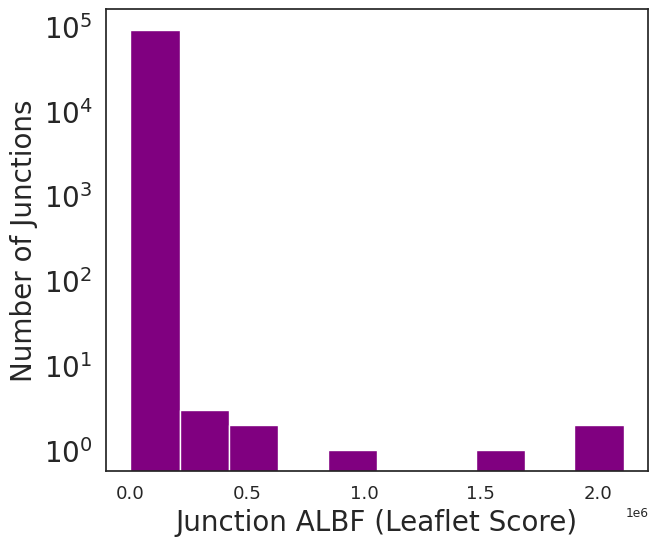

In [170]:
# make a histogram of the scores_all_juncs_df
plt.figure(figsize=(7, 6))
plt.hist(scores_all_juncs_df["score"], bins=10, color="purple", log=True)
plt.xlabel("Junction ALBF (Leaflet Score)", fontsize=20)
plt.ylabel("Number of Junctions", fontsize=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=20)

In [171]:
# make a version of the plot that shows that learned junction proportions across cell states 
from scipy.stats import beta

def quick_posterior_junc_plot(junc, ALPHAs, PIs, cell_states=None):
    
    junc_a = ALPHAs[junc, ]
    junc_b = PIs[junc, ]

    if cell_states:
        junc_a = junc_a[cell_states]
        junc_b = junc_b[cell_states]

    # Define a list of colors for the plot
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Add more colors if needed

    # Create a figure and axis for the plot with size 6x6
    fig, ax = plt.subplots(figsize=(5, 5))

    print(junc_a, junc_b)
    
    # Loop through each cell state and plot its beta distribution with a unique color
    for j, (a, b) in enumerate(zip(junc_a, junc_b)):
        
        x = np.linspace(beta.ppf(0.01, a, b),
                        beta.ppf(0.99, a, b), 100)
        
        color = colors[j % len(colors)]  # Cycle through colors if more cell states than colors
        label = f'Cell State {j + 1}'
        
        ax.plot(x, beta.pdf(x, a, b),
                color + '-', lw=2, alpha=0.6, label=label)
        
    # Add labels and legend with increased font size
    ax.set_xlabel('PSI', fontsize=20)
    ax.set_ylabel('Probability Density', fontsize=20)
    ax.set_title('Beta Distributions for junction ' + str(junc), fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    # Place the legend to the right of the plot
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
    plt.show()


tensor([1., 1.]) tensor([1., 3.])


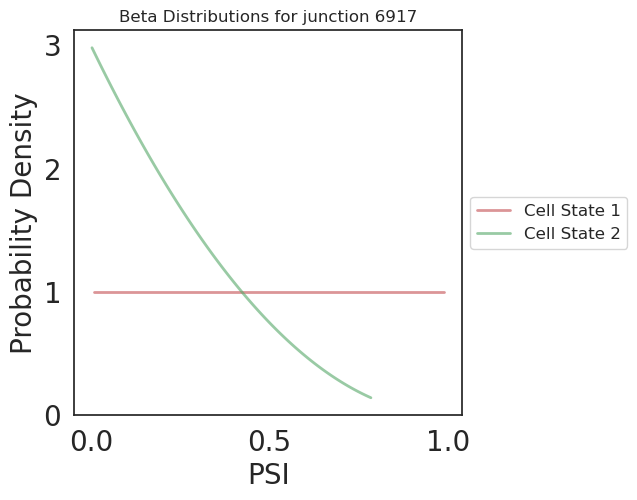

In [178]:
quick_posterior_junc_plot(6917, ALPHA_f, PI_f, cell_states=[0,6])

In [175]:
alpha_plus_pi_df_melt[alpha_plus_pi_df_melt["junction_id_index"] == 6917]

,junction_id_index,cell_state,alpha_plus_pi,percentile_rank
98271,6917,1,193.0,0.738672
189625,6917,2,274.0,0.778644
463687,6917,5,72.0,0.632118
1285873,6917,14,507.0,0.845482
1468581,6917,16,141.0,0.703170
1559935,6917,17,89.0,0.653435
1925351,6917,21,141.0,0.703170
2016705,6917,22,120.0,0.685185
2382121,6917,26,347.0,0.805023
2473475,6917,27,359.0,0.808821


innate lymphoid cell                                    24
B cell                                                  16
memory b cell                                           10
plasma cell                                             10
cd4-positive, alpha-beta memory t cell                   8
naive thymus-derived cd4-positive, alpha-beta t cell     7
CD4-positive alpha-beta thymocyte                        5
cd8-positive, alpha-beta memory t cell                   4
CD8-positive alpha-beta thymocyte                        4
nk cell                                                  2
T cell                                                   2
regulatory t cell                                        1
cd1c-positive myeloid dendritic cell                     1
Name: cell_type, dtype: int64


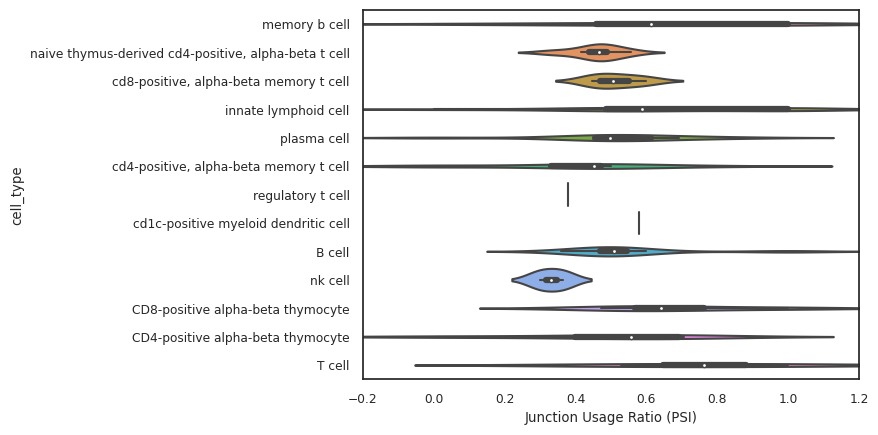

In [179]:
quick_junc_plot(6917, simple_data)

In [ ]:
quick_posterior_junc_plot(548, ALPHA_f, PI_f)

In [181]:
PHI_f

,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,...,CellState_44,CellState_45,CellState_46,CellState_47,CellState_48,CellState_49,CellState_50,CellState_51,cell_id,cell_type
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_Im...,"cd4-positive, alpha-beta memory t cell"
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_Im...,"cd8-positive, alpha-beta memory t cell"
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_Im...,"naive thymus-derived cd4-positive, alpha-beta ..."
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_Im...,"cd4-positive, alpha-beta memory t cell"
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TSP2_LymphNode_Inguinal_SS2_B113694_B133052_Im...,memory b cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TSP7_LymphNode_supradiaphragmatic_SS2_B134156_...,innate lymphoid cell
2379,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TSP7_LymphNode_supradiaphragmatic_SS2_B134156_...,plasma cell
2380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TSP7_LymphNode_supradiaphragmatic_SS2_B134156_...,plasma cell
2381,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TSP7_LymphNode_supradiaphragmatic_SS2_B134156_...,innate lymphoid cell


In [ ]:
# save cell assignments to file for downstream analysis
output_dir = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/'

# BBmixture model cell assignments
output_file = os.path.join(output_dir, 'Leaflet_BBmixture.csv')
PHI_f.to_csv(output_file, index=True, header=True)
print('Saved Leaflet latent cell states to {}'.format(output_file))